In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [23]:
df = pd.read_csv("winequality-white.csv",sep=';')

In [24]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.994,3.3,0.49,9.5,6


In [25]:
df.shape

(4898, 12)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [27]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [28]:
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

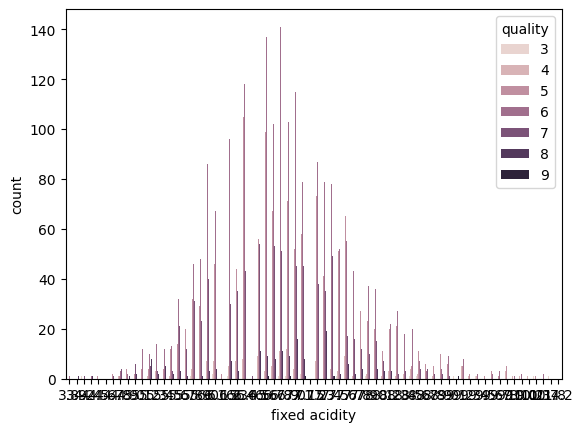

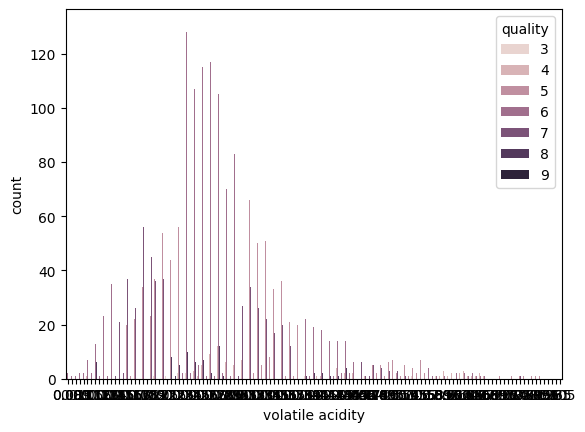

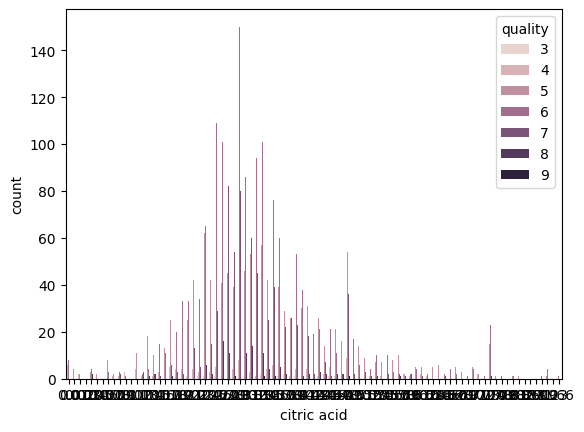

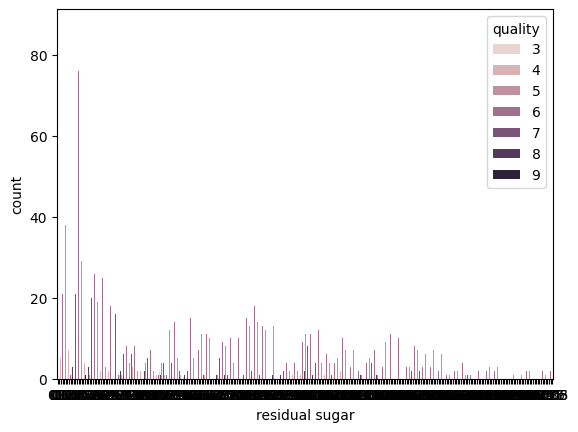

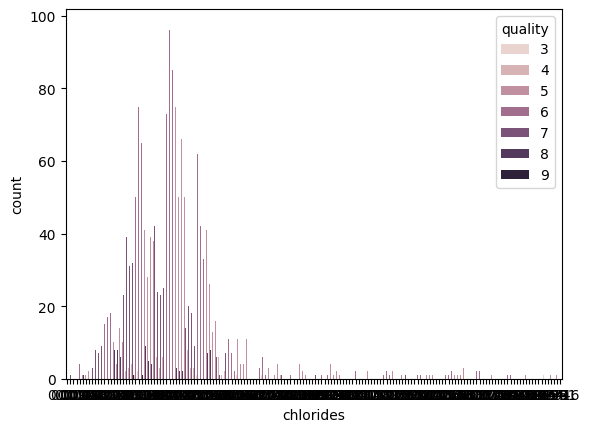

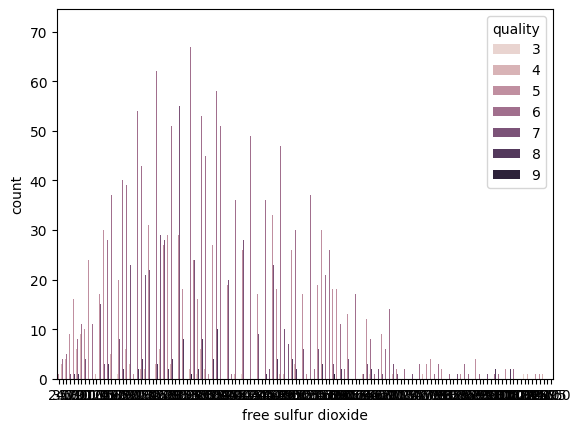

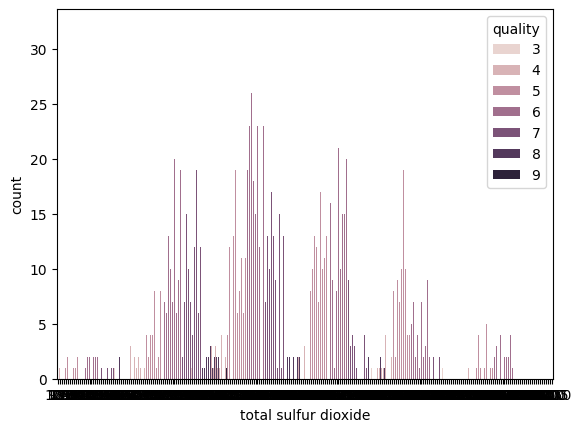

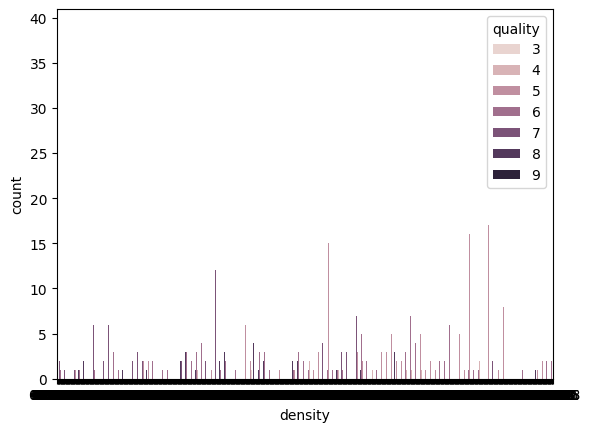

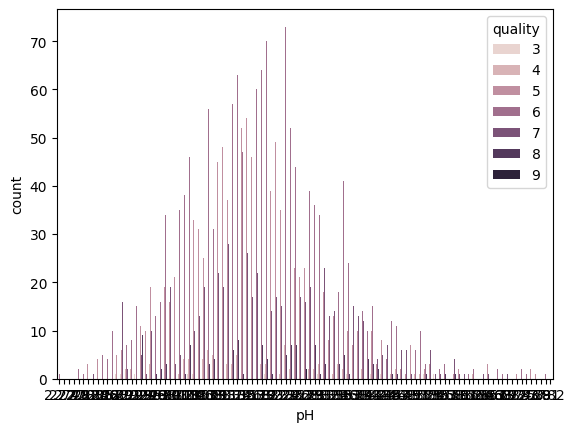

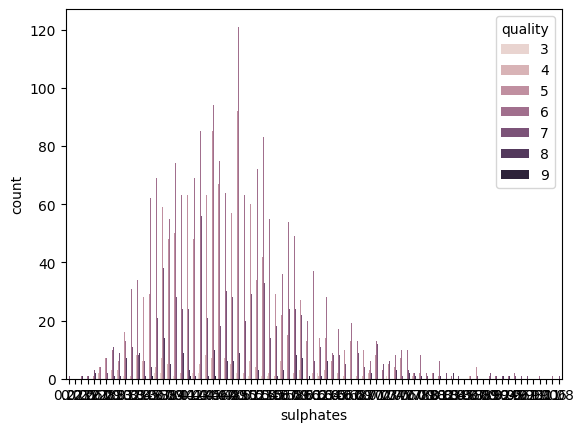

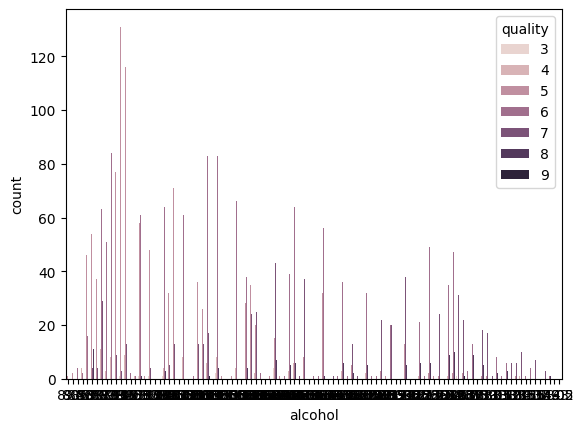

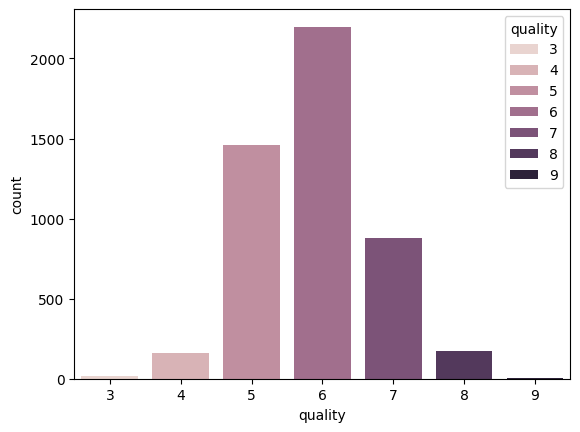

In [29]:
for col in df.columns:
  sns.countplot(x=col, data=df,hue=df['quality'])
  plt.show()

<Axes: >

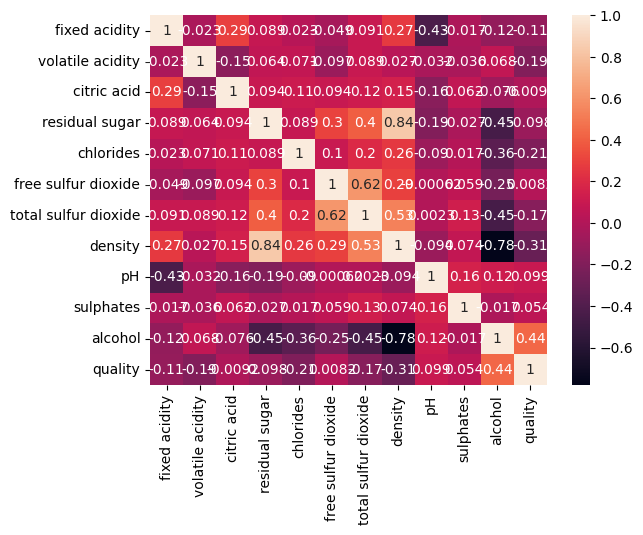

In [30]:
sns.heatmap(df.corr(),annot=True)

In [31]:
X = df.drop('quality',axis=1)
y = df['quality']

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
rf = RandomForestClassifier(n_estimators=300,random_state=42,class_weight="balanced")
rf.fit(X_train,y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [34]:
y_pred = rf.predict(X_test)

In [35]:
acc = accuracy_score(y_test,y_pred)
print(acc)

0.7061224489795919


In [36]:
from sklearn.model_selection import GridSearchCV
gs = GridSearchCV(estimator=rf,param_grid={'n_estimators':[100,150,200]},cv=5)
gs.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=RandomForestClassifier(class_weight='balanced',
                                              n_estimators=300,
                                              random_state=42),
             param_grid={'n_estimators': [100, 150, 200]})

In [37]:
pred = gs.predict(X_test)

In [38]:
acc = accuracy_score(y_test,pred)
print(acc)

0.7091836734693877


In [39]:
from sklearn.model_selection import cross_val_score

In [40]:
cv = cross_val_score(rf,X,y,cv=5)

In [41]:
cv

array([0.5122449 , 0.49183673, 0.58469388, 0.54136874, 0.53626149])

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=4)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_resampled.value_counts())

quality
6    1766
5    1766
7    1766
3    1766
4    1766
8    1766
9    1766
Name: count, dtype: int64


In [45]:
rf.fit(X_train_resampled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [46]:
pred = rf.predict(X_test)

In [47]:
acc = accuracy_score(y_test,pred)
print(acc)

0.6591836734693878
